# ConvAE demo

This notebook loads a synthetic data cube and a fixed source mask from
`../data/tutorial_demo.fits`, generated by `tutorial_demo_frame.ipynb`, and fits
the `comicsnet.ConvAE` background model.

The data cube contains a time-variable background and a moving compact
source. Each optimization step uses one complete detector frame. The
model reconstructs the background with a convolutional autoencoder while
excluding masked pixels from the reconstruction loss.


In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import jax
import astropy.io.fits as fits

from comicsnet import Config, ConvAE, fit

rcParams['image.origin'] = 'lower'
rcParams['legend.frameon'] = False

## Demo data

Load the data cube from the primary HDU and the source mask from the
`MASK` extension. Both have shape `(time, y, x)`. Mask values of 1 mark
pixels excluded from background fitting; values of 0 mark observed pixels.


In [2]:
cube = fits.open('../data/tutorial_demo.fits')[0].data
mask = fits.open('../data/tutorial_demo.fits')['MASK'].data
nz, ny, nx = cube.shape

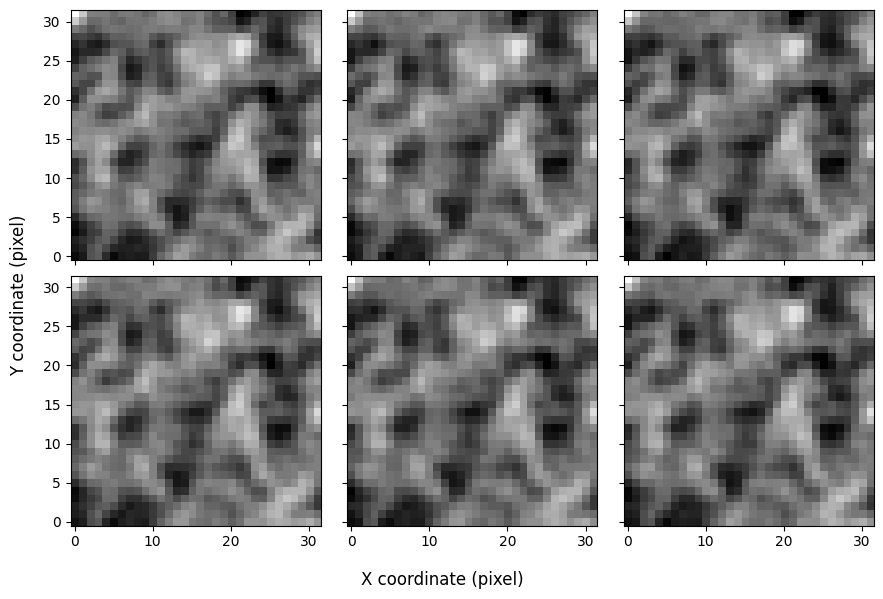

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
  ax.imshow(cube[n], cmap='gray')

fig.supxlabel('X coordinate (pixel)', fontsize=12)
fig.supylabel('Y coordinate (pixel)', fontsize=12)

fig.tight_layout()
plt.show()

## Fit ConvAE with a fixed mask

Pass the source mask using `fit(model, cube, mask=mask, config=config)`.
With `update_mask=False`, this mask stays fixed throughout training and
final prediction, and is returned as `result.mask` after conversion to bool.

Internally, observation weights are `1 - mask`. The encoder starts with
the weighted image, observation weight, and x/y coordinate planes
normalized to [0, 1]. It appends pairs of `cos(2*pi*n*x)` and
`cos(2*pi*n*y)` for `n = 1, ..., N`, where `N = coordinate_max_frequency`.
The default `N = 4` gives 12 input channels; `N = 0` retains the four
base channels. All coordinate channels remain visible at masked pixels.

Two 2x2 pooling steps reduce each spatial dimension by a factor of four.
The latent representation is a feature map with `latent_channels`
channels. The decoder uses two bilinear upsampling steps and separate
output layers for the background mean and log variance. Predictions
cover the full frame, including masked pixels. Use image dimensions
divisible by four to preserve the input size at the output.

Adjust `hidden_channels` and `latent_channels` for model capacity, and
`inner_steps` and `outer_steps` for the number of optimization steps.
No frame number or time coordinate is supplied.


In [4]:
config = Config(
  outer_steps=5,
  inner_steps=10000,
  learning_rate=1.0e-4,
  beta=1e-4,
  update_mask=False,
  seed=1,
)

model_key = jax.random.PRNGKey(2)
model = ConvAE(
  hidden_channels=64,
  latent_channels=2,
  coordinate_max_frequency=4,
  key=model_key,
)

result = fit(model, cube, mask=mask, config=config)

The plot shows the last 2,000 optimization steps. Each loss value is the
Gaussian negative log likelihood averaged over unmasked pixels in one
randomly selected frame, using standardized data. The fixed mask is used
at every step; the loss is not evaluated over the full data cube.
ConvAE has no KL term, so `beta` does not affect its loss.


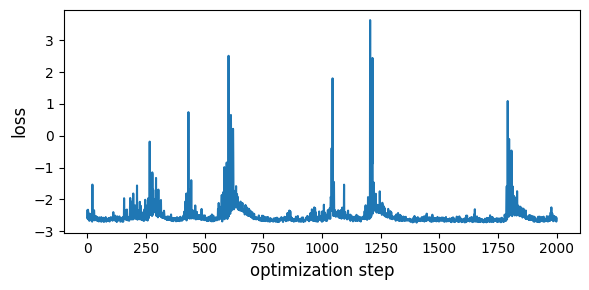

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(result.losses[-2000:])

ax.set_xlabel('optimization step', fontsize=12)
ax.set_ylabel('loss', fontsize=12)

fig.tight_layout()
plt.show()

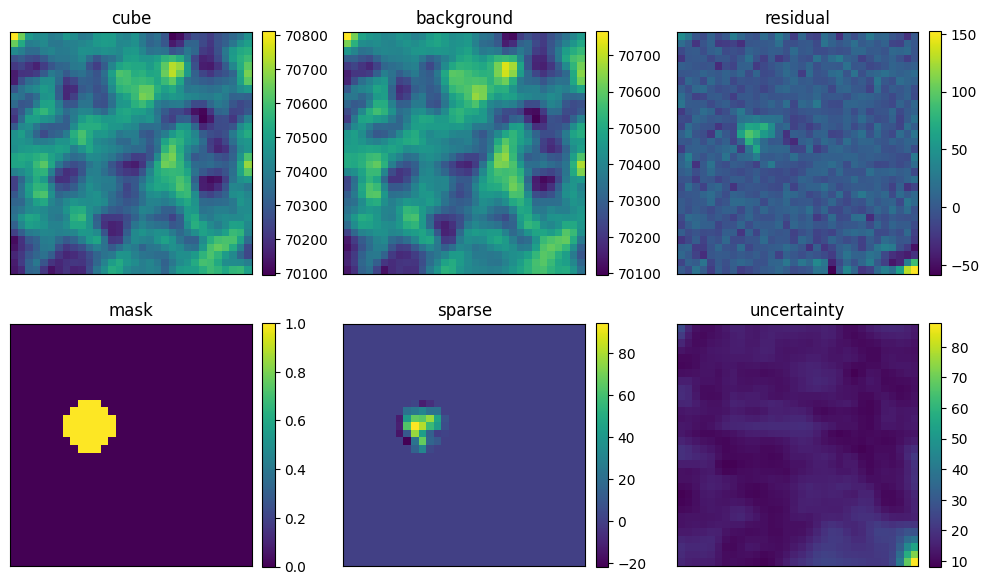

In [6]:
frame_index = 8

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
items = [
  ('cube', cube[frame_index]),
  ('background', result.background[frame_index]),
  ('residual', result.residual[frame_index]),
  ('mask', result.mask[frame_index]),
  ('sparse', result.sparse[frame_index]),
  ('uncertainty', result.uncertainty[frame_index]),
]

for axis, (title, image) in zip(axes.ravel(), items):
  handle = axis.imshow(image, origin='lower', cmap='viridis')
  axis.set_title(title)
  axis.set_xticks([])
  axis.set_yticks([])
  fig.colorbar(handle, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

In [7]:
hdul = fits.HDUList([
  fits.PrimaryHDU(data=result.residual),
  fits.ImageHDU(data=result.background, name='MODEL'),
  fits.ImageHDU(data=result.mask.astype('int16'), name='MASK'),
  fits.ImageHDU(data=result.uncertainty, name='ERROR'),
])
hdul.writeto('../data/convAE.fits', overwrite=True)

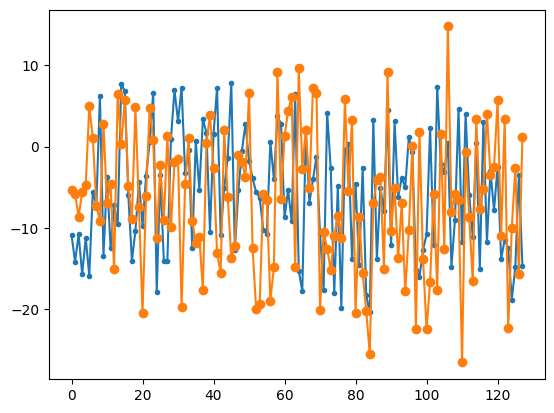

In [8]:
plt.plot(result.background[:, 10, 10] - result.data[:, 10, 10], marker='.')
plt.plot(result.background[:, 30, 30] - result.data[:, 30, 30], marker='o')